<a href="https://colab.research.google.com/github/silviaparente/computational_astrobiology/blob/main/Copia_di_computational_astrobiology_real_spectra_gpu_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computational Astrobiology with **Real Spectra** and GPU Acceleration in Google Colab

This notebook is a **master-level exercise** in computational astrobiology using **public archived spectra** rather than synthetic data.

The science focus is the **MUSCLES / Mega-MUSCLES** stellar spectral energy distributions hosted by **MAST**. These are public high-level science products that provide **X-ray to infrared spectra** of exoplanet host stars and were assembled specifically for **exoplanet atmosphere modeling**. The archive documentation states that the MUSCLES family provides complete spectra from X-ray to IR for use in exoplanet atmosphere modeling, and that the data are available programmatically through `astroquery.mast` with `provenance_name="muscles"`. citeturn630111view0turn539152view0

Why this is a strong astrobiology exercise:
- these are **real, published spectra**
- the wavelength coverage is directly relevant to **planetary atmospheres, photochemistry, and habitability**
- students can combine **data access, spectral analysis, UV-band integration, and GPU-based representation learning**

## Learning goals

By the end of this notebook, the student should be able to:
1. query and download real spectra from a public astronomical archive,
2. inspect FITS spectral products,
3. compare host-star spectral energy distributions,
4. compute simple **astrobiology-relevant UV dose proxies**,
5. resample heterogeneous spectra onto a common grid,
6. train a small **GPU-accelerated autoencoder** on real spectra,
7. interpret latent representations physically rather than treating ML as a black box.

## Data provenance

We use MUSCLES / Mega-MUSCLES spectral energy distributions from MAST. The official MAST page documents:
- the scientific purpose of the dataset,
- the target lists across releases,
- the file naming convention,
- the main SED products such as `const-res-sed` and `adapt-const-res-sed`,
- and direct `astroquery` access via `Observations.query_criteria(provenance_name="muscles")`. citeturn630111view0turn539152view0

## Recommended Colab runtime

In Colab:
1. go to **Runtime → Change runtime type**
2. choose **GPU**
3. run the next cell

In [1]:
# GPU check
import sys, platform, subprocess, os

try:
    import torch
except Exception:
    torch = None

print("Python:", sys.version)
print("Platform:", platform.platform())

if torch is None:
    print("PyTorch is not installed yet in this runtime.")
else:
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4


## Install dependencies

This notebook uses:
- `astroquery` to access MAST,
- `astropy` to read FITS tables,
- `torch` for GPU-accelerated learning,
- and standard scientific Python packages.

If you are re-running the notebook in a fresh Colab session, execute this once.

In [2]:
%%capture
!pip -q install astroquery astropy torch torchvision torchaudio scikit-learn pandas matplotlib

## Imports

In [3]:
import os
import re
import time
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astroquery.mast import Observations
from astropy.io import fits
from astropy.table import Table

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)

## Part 1 — Query the MAST archive for real MUSCLES spectra

The official MAST documentation shows that MUSCLES products can be queried with:

```python
from astroquery.mast import Observations
all_obs = Observations.query_criteria(provenance_name="muscles")
```

and that the primary SED products include:
- `const-res-sed.fits`
- `var-res-sed.fits`
- `adapt-const-res-sed.fits`
- `adapt-var-res-sed.fits` citeturn539152view0

Here we retrieve the product inventory and then keep only the **adapted constant-resolution SEDs**, which are convenient for teaching because they are already smoothed in low-S/N regions and easier to compare across targets. The MAST page describes `adapt-const-res-sed.fits` as a panchromatic SED binned to a constant 1 Å resolution and downsampled in low-S/N regions to avoid negative fluxes. citeturn539152view0

In [4]:
# Query all MUSCLES observations and get the associated product list
all_obs = Observations.query_criteria(provenance_name="muscles")
products = Observations.get_product_list(all_obs)

print("Number of observation rows:", len(all_obs))
print("Number of product rows:", len(products))

# Convert to pandas for easier filtering and display
prod_df = products.to_pandas()
display(prod_df.head())

Number of observation rows: 35
Number of product rows: 481


,obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
0,283127402,HLSP,spectrum,hlsp_muscles_gj1214,Preview-Full,S,mast:HLSP/muscles/v22/gj1214/hlsp_muscles_mult...,PREVIEW,NaN,NaN,NaN,MUSCLES,NaN,13650,hlsp_muscles_multi_multi_gj1214_multi_v22_comp...,159749,283127402,PUBLIC,4,MULTI
1,283127402,HLSP,spectrum,hlsp_muscles_gj1214,FITS,S,mast:HLSP/muscles/v22/gj1214/hlsp_muscles_hst_...,SCIENCE,Minimum Recommended Products,NaN,NaN,MUSCLES,NaN,13650,hlsp_muscles_hst_cos_gj1214_g130m_v22_componen...,2157120,283127402,PUBLIC,4,MULTI
2,283127402,HLSP,spectrum,hlsp_muscles_gj1214,FITS,S,mast:HLSP/muscles/v22/gj1214/hlsp_muscles_hst_...,SCIENCE,Minimum Recommended Products,NaN,NaN,MUSCLES,NaN,13650,hlsp_muscles_hst_cos_gj1214_g160m_v22_componen...,2119680,283127402,PUBLIC,4,MULTI
3,283127402,HLSP,spectrum,hlsp_muscles_gj1214,FITS,S,mast:HLSP/muscles/v22/gj1214/hlsp_muscles_hst_...,SCIENCE,Minimum Recommended Products,NaN,NaN,MUSCLES,NaN,13650,hlsp_muscles_hst_cos_gj1214_g230l_v22_componen...,152640,283127402,PUBLIC,4,MULTI
4,283127402,HLSP,spectrum,hlsp_muscles_gj1214,FITS,S,mast:HLSP/muscles/v22/gj1214/hlsp_muscles_hst_...,SCIENCE,Minimum Recommended Products,NaN,NaN,MUSCLES,NaN,13650,hlsp_muscles_hst_stis_gj1214_g140m_v22_compone...,86400,283127402,PUBLIC,4,MULTI


## Choose a target subset

To keep download size reasonable for a course notebook, we select a manageable subset of stars.

The MUSCLES/Mega-MUSCLES documentation explicitly lists targets such as:
- TRAPPIST-1
- Proxima Cen
- GJ 176
- GJ 436
- GJ 581
- GJ 667C
- GJ 832
- HD 40307
- HD 85512
- HD 97658
- ε Eri / Eps Eri
- and later extensions with additional targets. citeturn630111view0

You can change the list below.

In [5]:
# These are filename slugs, not necessarily the human-readable target names.
# Keeping them as slugs makes filename filtering more robust.
target_slugs = [
    "trappist-1",
    "gj176",
    "gj436",
    "gj581",
    "gj667c",
    "gj832",
    "hd-40307",
    "hd-85512",
    "hd-97658",
    "proxima-cen",
    "v-eps-eri"
]

product_col = "productFilename" if "productFilename" in prod_df.columns else "productFilename".lower()
filename_series = prod_df[product_col].astype(str)

# Keep adapted constant-resolution SEDs only
sed_mask = filename_series.str.contains("adapt-const-res-sed.fits", case=False, na=False)
sed_df = prod_df.loc[sed_mask].copy()

# Extract version and target slug from filename
def extract_version(fname):
    m = re.search(r"_v(\d+)_", str(fname).lower())
    return int(m.group(1)) if m else -1

def find_slug(fname, slugs):
    f = str(fname).lower()
    matches = [s for s in slugs if f"_{s}_" in f]
    return matches[0] if matches else None

sed_df["version_num"] = sed_df[product_col].apply(extract_version)
sed_df["target_slug"] = sed_df[product_col].apply(lambda x: find_slug(x, target_slugs))

selected = sed_df[sed_df["target_slug"].notna()].copy()

# Keep newest version per target
selected = (
    selected.sort_values(["target_slug", "version_num"], ascending=[True, False])
            .drop_duplicates(subset=["target_slug"], keep="first")
            .sort_values("target_slug")
)

display(selected[[product_col, "target_slug", "version_num"]].reset_index(drop=True))
print("Selected targets:", selected["target_slug"].tolist())

,productFilename,target_slug,version_num
0,hlsp_muscles_multi_multi_gj176_broadband_v22_a...,gj176,22
1,hlsp_muscles_multi_multi_gj436_broadband_v22_a...,gj436,22
2,hlsp_muscles_multi_multi_gj581_broadband_v22_a...,gj581,22
3,hlsp_muscles_multi_multi_gj667c_broadband_v22_...,gj667c,22
4,hlsp_muscles_multi_multi_gj832_broadband_v22_a...,gj832,22
5,hlsp_muscles_multi_multi_trappist-1_broadband_...,trappist-1,25
6,hlsp_muscles_multi_multi_v-eps-eri_broadband_v...,v-eps-eri,22


Selected targets: ['gj176', 'gj436', 'gj581', 'gj667c', 'gj832', 'trappist-1', 'v-eps-eri']


## Download the selected files

In [6]:
download_dir = Path("mast_downloads")
download_dir.mkdir(exist_ok=True)

manifest = Observations.download_products(
    Table.from_pandas(selected),
    download_dir=str(download_dir),
    mrp_only=False
)

manifest_df = manifest.to_pandas() if hasattr(manifest, "to_pandas") else pd.DataFrame(manifest)
display(manifest_df.head())

# Keep successful downloads
path_col = None
for c in manifest_df.columns:
    if c.lower().replace(" ", "_") in {"local_path", "localpath"}:
        path_col = c
        break

if path_col is None:
    raise RuntimeError("Could not identify local path column in the download manifest.")

local_paths = [Path(p) for p in manifest_df[path_col] if isinstance(p, str) and os.path.exists(p)]
print("Downloaded files:", len(local_paths))
for p in local_paths[:10]:
    print(p)

,Local Path,Status,Message,URL
0,mast_downloads/mastDownload/HLSP/hlsp_muscles_...,COMPLETE,None,None
1,mast_downloads/mastDownload/HLSP/hlsp_muscles_...,COMPLETE,None,None
2,mast_downloads/mastDownload/HLSP/hlsp_muscles_...,COMPLETE,None,None
3,mast_downloads/mastDownload/HLSP/hlsp_muscles_...,COMPLETE,None,None
4,mast_downloads/mastDownload/HLSP/hlsp_muscles_...,COMPLETE,None,None


Downloaded files: 7
mast_downloads/mastDownload/HLSP/hlsp_muscles_gj176/hlsp_muscles_multi_multi_gj176_broadband_v22_adapt-const-res-sed.fits
mast_downloads/mastDownload/HLSP/hlsp_muscles_gj436/hlsp_muscles_multi_multi_gj436_broadband_v22_adapt-const-res-sed.fits
mast_downloads/mastDownload/HLSP/hlsp_muscles_gj581/hlsp_muscles_multi_multi_gj581_broadband_v22_adapt-const-res-sed.fits
mast_downloads/mastDownload/HLSP/hlsp_muscles_gj667c/hlsp_muscles_multi_multi_gj667c_broadband_v22_adapt-const-res-sed.fits
mast_downloads/mastDownload/HLSP/hlsp_muscles_gj832/hlsp_muscles_multi_multi_gj832_broadband_v22_adapt-const-res-sed.fits
mast_downloads/mastDownload/HLSP/hlsp_muscles_trappist-1/hlsp_muscles_multi_multi_trappist-1_broadband_v25_adapt-const-res-sed.fits
mast_downloads/mastDownload/HLSP/hlsp_muscles_v-eps-eri/hlsp_muscles_multi_multi_v-eps-eri_broadband_v22_adapt-const-res-sed.fits


## Inspect one FITS file

Before writing analysis code, it is good scientific practice to inspect the actual file structure.

In [7]:
example_path = local_paths[0]
print("Example file:", example_path)

with fits.open(example_path) as hdul:
    print(hdul.info())
    for i, hdu in enumerate(hdul):
        if hasattr(hdu, "columns") and hdu.columns is not None:
            print(f"\nHDU {i} columns:")
            print(hdu.columns)

Example file: mast_downloads/mastDownload/HLSP/hlsp_muscles_gj176/hlsp_muscles_multi_multi_gj176_broadband_v22_adapt-const-res-sed.fits
Filename: mast_downloads/mastDownload/HLSP/hlsp_muscles_gj176/hlsp_muscles_multi_multi_gj176_broadband_v22_adapt-const-res-sed.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      57   ()      
  1  SPECTRUM      1 BinTableHDU     59   54994R x 13C   [D, D, D, D, D, D, I, D, D, J, D, D, D]   
  2  INSTLGND      1 BinTableHDU     32   24R x 5C   [J, 5A, 18A, 6A, 70A]   
None

HDU 1 columns:
ColDefs(
    name = 'WAVELENGTH'; format = 'D'; unit = 'Angstrom'
    name = 'WAVELENGTH0'; format = 'D'; unit = 'Angstrom'
    name = 'WAVELENGTH1'; format = 'D'; unit = 'Angstrom'
    name = 'FLUX'; format = 'D'; unit = 'erg / (Angstrom cm2 s)'
    name = 'ERROR'; format = 'D'; unit = 'erg / (Angstrom cm2 s)'
    name = 'EXPTIME'; format = 'D'; unit = 's'
    name = 'DQ'; format = 'I'
    name = 'EXPSTART'; format 

## Helper function to read a MUSCLES SED

The MAST documentation gives the naming scheme and product types, but the exact FITS table column labels are best read directly from the file. The function below tries common column names used in spectral FITS products and falls back to a simple heuristic if needed. The MUSCLES documentation states that these SEDs are panchromatic spectra from X-ray to infrared. citeturn630111view0

In [8]:
def read_muscles_sed(path):
    path = Path(path)
    with fits.open(path) as hdul:
        table_hdu = None
        for hdu in hdul:
            if hasattr(hdu, "columns") and hdu.columns is not None and len(hdu.columns) > 0:
                table_hdu = hdu
                break

        if table_hdu is None:
            raise ValueError(f"No table HDU found in {path}")

        tbl = Table(table_hdu.data)
        colnames = list(tbl.colnames)
        upper = {c.upper(): c for c in colnames}

        wave_candidates = ["WAVELENGTH", "WAVE", "LAMBDA", "WL"]
        flux_candidates = ["FLUX", "FLUX_DENSITY", "FLUXDEN", "FNU", "FLAM"]
        err_candidates  = ["ERROR", "ERR", "SIGMA", "FLUX_ERROR", "UNCERTAINTY"]

        wave_col = next((upper[c] for c in wave_candidates if c in upper), None)
        flux_col = next((upper[c] for c in flux_candidates if c in upper), None)
        err_col  = next((upper[c] for c in err_candidates if c in upper), None)

        # Fallback heuristic: choose first float-like columns
        if wave_col is None or flux_col is None:
            numeric_cols = []
            for c in colnames:
                arr = np.asarray(tbl[c])
                if np.issubdtype(arr.dtype, np.number):
                    numeric_cols.append(c)
            if wave_col is None and len(numeric_cols) >= 1:
                wave_col = numeric_cols[0]
            if flux_col is None and len(numeric_cols) >= 2:
                flux_col = numeric_cols[1]

        wave = np.asarray(tbl[wave_col], dtype=float)
        flux = np.asarray(tbl[flux_col], dtype=float)
        err = np.asarray(tbl[err_col], dtype=float) if err_col is not None else np.full_like(flux, np.nan)

    target = path.name.lower()
    target = re.sub(r"^.*?_muscles_[^_]+_[^_]+_", "", target)
    target = re.sub(r"_na_v\d+_.*$", "", target)

    return {
        "path": str(path),
        "target_slug": target,
        "wavelength_A": wave,
        "flux": flux,
        "error": err,
        "wave_col": wave_col,
        "flux_col": flux_col,
        "err_col": err_col,
    }

spectra = [read_muscles_sed(p) for p in local_paths]

summary = pd.DataFrame({
    "target_slug": [s["target_slug"] for s in spectra],
    "n_points": [len(s["wavelength_A"]) for s in spectra],
    "wave_col": [s["wave_col"] for s in spectra],
    "flux_col": [s["flux_col"] for s in spectra],
    "err_col": [s["err_col"] for s in spectra],
    "path": [Path(s["path"]).name for s in spectra]
}).sort_values("target_slug")

display(summary)

,target_slug,n_points,wave_col,flux_col,err_col,path
0,gj176_broadband_v22_adapt-const-res-sed.fits,54994,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_gj176_broadband_v22_a...
1,gj436_broadband_v22_adapt-const-res-sed.fits,54994,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_gj436_broadband_v22_a...
2,gj581_broadband_v22_adapt-const-res-sed.fits,54994,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_gj581_broadband_v22_a...
3,gj667c_broadband_v22_adapt-const-res-sed.fits,54994,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_gj667c_broadband_v22_...
4,gj832_broadband_v22_adapt-const-res-sed.fits,54994,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_gj832_broadband_v22_a...
5,trappist-1_broadband_v25_adapt-const-res-sed.fits,129988,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_trappist-1_broadband_...
6,v-eps-eri_broadband_v22_adapt-const-res-sed.fits,54996,WAVELENGTH,FLUX,ERROR,hlsp_muscles_multi_multi_v-eps-eri_broadband_v...


## Part 2 — Plot the real spectra

MUSCLES spectra span a very broad dynamic range, so logarithmic axes are appropriate.

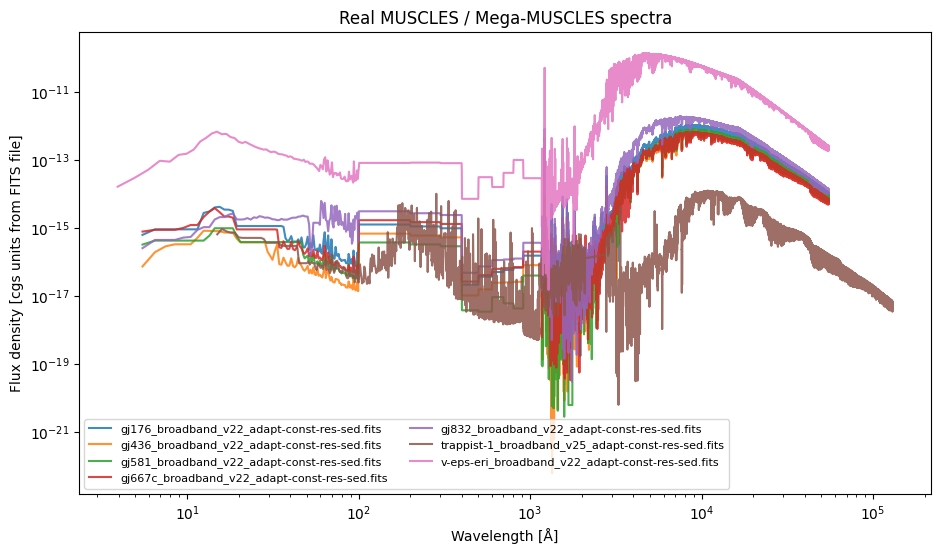

In [9]:
plt.figure(figsize=(11, 6))

for s in sorted(spectra, key=lambda x: x["target_slug"]):
    wl = s["wavelength_A"]
    flux = s["flux"]

    m = np.isfinite(wl) & np.isfinite(flux) & (wl > 0) & (flux > 0)
    plt.loglog(wl[m], flux[m], label=s["target_slug"], alpha=0.85)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux density [cgs units from FITS file]")
plt.title("Real MUSCLES / Mega-MUSCLES spectra")
plt.legend(fontsize=8, ncol=2)
plt.show()

### Focus on the UV

In astrobiology, the UV part of the spectrum is often especially important because it can both:
- drive prebiotic photochemistry,
- and increase atmospheric erosion or biological damage, depending on environment and shielding.

This makes the UV region a natural first quantitative exercise.

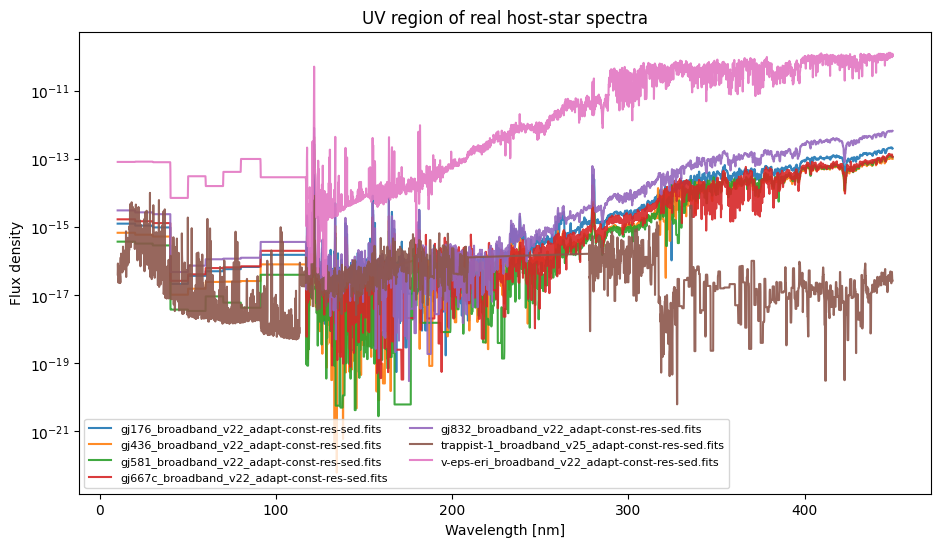

In [10]:
plt.figure(figsize=(11, 6))

for s in sorted(spectra, key=lambda x: x["target_slug"]):
    wl = s["wavelength_A"] / 10.0  # Å -> nm
    flux = s["flux"]
    m = np.isfinite(wl) & np.isfinite(flux) & (wl > 10) & (wl < 450) & (flux > 0)
    plt.semilogy(wl[m], flux[m], label=s["target_slug"], alpha=0.9)

plt.xlabel("Wavelength [nm]")
plt.ylabel("Flux density")
plt.title("UV region of real host-star spectra")
plt.legend(fontsize=8, ncol=2)
plt.show()

## Part 3 — Astrobiology proxy calculations

We define simple UV band integrals:

- **UV-C**: 100–280 nm
- **UV-B**: 280–315 nm
- **UV-A**: 315–400 nm

These are not full atmospheric dose models. They are intentionally simple **first-order proxies** for comparing stellar radiation fields. For a stronger project, the student could later fold the spectra through:
- atmospheric transmission,
- photochemical cross-sections,
- or a wavelength-dependent biological action spectrum.

In [11]:
def band_integral_nm(wavelength_A, flux, lo_nm, hi_nm):
    wl_nm = wavelength_A / 10.0
    m = (
        np.isfinite(wl_nm) &
        np.isfinite(flux) &
        (wl_nm >= lo_nm) &
        (wl_nm < hi_nm) &
        (flux > 0)
    )
    if m.sum() < 2:
        return np.nan
    return np.trapz(flux[m], wl_nm[m])

def broad_integral_nm(wavelength_A, flux, lo_nm=100.0, hi_nm=1000.0):
    return band_integral_nm(wavelength_A, flux, lo_nm, hi_nm)

rows = []
for s in spectra:
    uvc = band_integral_nm(s["wavelength_A"], s["flux"], 100, 280)
    uvb = band_integral_nm(s["wavelength_A"], s["flux"], 280, 315)
    uva = band_integral_nm(s["wavelength_A"], s["flux"], 315, 400)
    total = broad_integral_nm(s["wavelength_A"], s["flux"], 100, 1000)

    rows.append({
        "target_slug": s["target_slug"],
        "UV-C": uvc,
        "UV-B": uvb,
        "UV-A": uva,
        "100-1000nm_total": total,
        "UV-C_frac": uvc / total if np.isfinite(total) and total > 0 else np.nan,
        "UV-B_frac": uvb / total if np.isfinite(total) and total > 0 else np.nan,
        "UV-A_frac": uva / total if np.isfinite(total) and total > 0 else np.nan,
    })

uv_df = pd.DataFrame(rows).sort_values("target_slug")

def safe_style(df, sci_notation_cols=None, float_cols=None):
    sci_notation_cols = sci_notation_cols or []
    float_cols = float_cols or []

    fmt = {}
    for col in sci_notation_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            fmt[col] = "{:.3e}"
    for col in float_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            fmt[col] = "{:.4f}"

    return df.style.format(fmt)

display(safe_style(uv_df, sci_notation_cols=["flux", "error"], float_cols=["wavelength"]))

,target_slug,UV-C,UV-B,UV-A,100-1000nm_total,UV-C_frac,UV-B_frac,UV-A_frac
0,gj176_broadband_v22_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.000267,0.000285,0.007739
1,gj436_broadband_v22_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.000189,0.000178,0.006320
2,gj581_broadband_v22_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.000089,0.000128,0.005764
3,gj667c_broadband_v22_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.000327,0.000278,0.006553
4,gj832_broadband_v22_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.000241,0.000379,0.010213
5,trappist-1_broadband_v25_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.011517,0.003631,0.003986
6,v-eps-eri_broadband_v22_adapt-const-res-sed.fits,0.000000,0.000000,0.000000,0.000000,0.001968,0.012252,0.060234


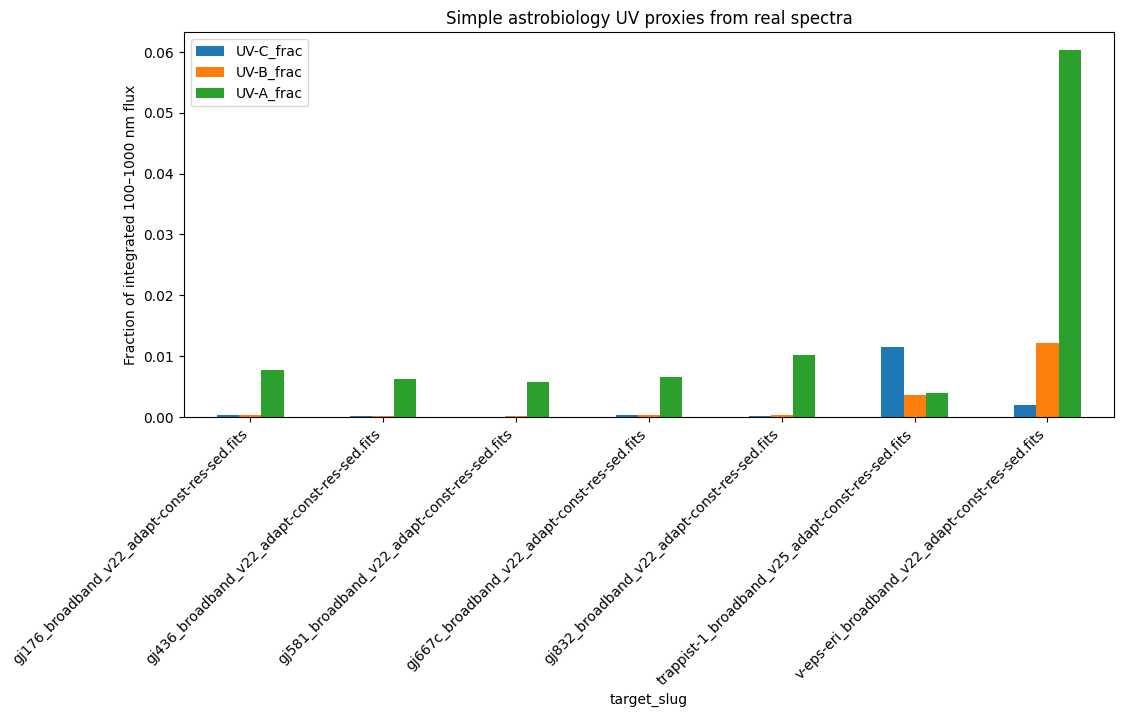

In [12]:
# Plot UV fractions
plot_df = uv_df.set_index("target_slug")[["UV-C_frac", "UV-B_frac", "UV-A_frac"]]

plot_df.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Fraction of integrated 100–1000 nm flux")
plt.title("Simple astrobiology UV proxies from real spectra")
plt.xticks(rotation=45, ha="right")
plt.show()

### Discussion prompt

At this stage, the student should already ask:

1. Which stars are relatively UV-hard or UV-soft?
2. Are there clusters in UV behavior?
3. Which targets might be most interesting for follow-up photochemistry modeling?
4. What important physics is *missing* from this simple comparison?

That last question matters a lot. These fluxes are as represented in the archive products, not yet propagated to a specific planet's top-of-atmosphere environment in a self-consistent habitable-zone framework.

## Part 4 — Put the spectra on a common grid

Machine-learning models need a common feature representation. We resample every spectrum onto the same wavelength grid in log-wavelength space.

This is also scientifically sensible because stellar SEDs span many decades in wavelength and flux.

In [13]:
# Common grid for ML
grid_A = np.geomspace(10, 1e5, 2048)  # 1 nm to 10 microns in Å
log_grid = np.log10(grid_A)

def resample_spectrum(wavelength_A, flux, grid_A):
    wl = np.asarray(wavelength_A, dtype=float)
    fl = np.asarray(flux, dtype=float)

    m = np.isfinite(wl) & np.isfinite(fl) & (wl > 0) & (fl > 0)
    wl = wl[m]
    fl = fl[m]

    order = np.argsort(wl)
    wl = wl[order]
    fl = fl[order]

    if len(wl) < 10:
        return np.full_like(grid_A, np.nan, dtype=float)

    x = np.log10(wl)
    y = np.log10(fl)

    interp = np.interp(np.log10(grid_A), x, y, left=np.nan, right=np.nan)
    out = 10 ** interp
    return out

X_real = []
names = []

for s in spectra:
    spec = resample_spectrum(s["wavelength_A"], s["flux"], grid_A)
    X_real.append(spec)
    names.append(s["target_slug"])

X_real = np.array(X_real)

print("Resampled matrix shape:", X_real.shape)
print("Targets:", names)

Resampled matrix shape: (7, 2048)
Targets: ['gj176_broadband_v22_adapt-const-res-sed.fits', 'gj436_broadband_v22_adapt-const-res-sed.fits', 'gj581_broadband_v22_adapt-const-res-sed.fits', 'gj667c_broadband_v22_adapt-const-res-sed.fits', 'gj832_broadband_v22_adapt-const-res-sed.fits', 'trappist-1_broadband_v25_adapt-const-res-sed.fits', 'v-eps-eri_broadband_v22_adapt-const-res-sed.fits']


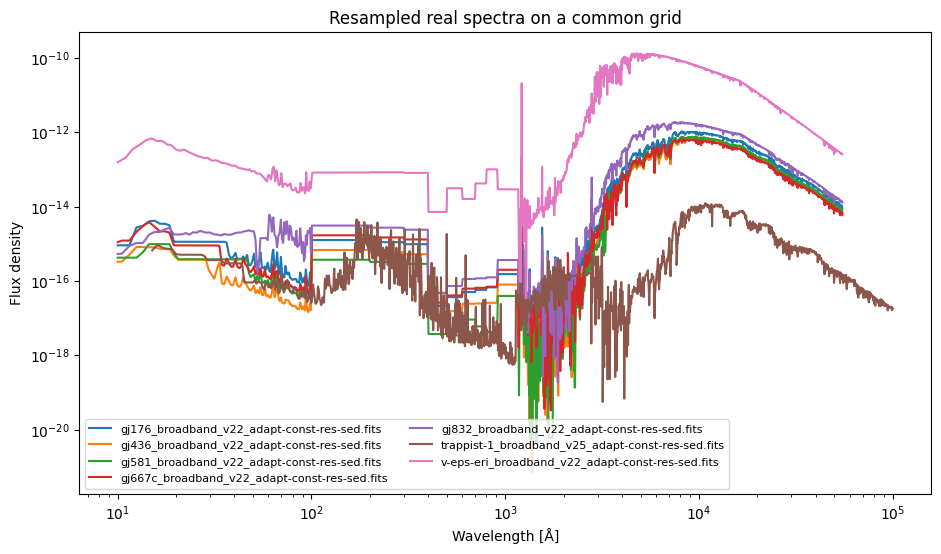

In [14]:
# Visualize resampled spectra
plt.figure(figsize=(11, 6))

for i, name in enumerate(names):
    y = X_real[i]
    m = np.isfinite(y) & (y > 0)
    plt.loglog(grid_A[m], y[m], label=name)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux density")
plt.title("Resampled real spectra on a common grid")
plt.legend(fontsize=8, ncol=2)
plt.show()

## Normalize for representation learning

For unsupervised ML, we usually want the model to focus on **shape** rather than trivial scale differences.

We therefore:
1. take `log10(flux)`,
2. replace missing values with per-spectrum minima,
3. standardize across the dataset.

Because there are only a modest number of real stars, we will later use **augmentation** to create perturbed training examples while keeping the underlying spectra real.

In [15]:
# Log-transform and fill
X_log = np.log10(X_real)
finite_mask = np.isfinite(X_log)

X_filled = X_log.copy()
for i in range(X_filled.shape[0]):
    row = X_filled[i]
    if np.isfinite(row).any():
        fill_value = np.nanmin(row[np.isfinite(row)])
        row[~np.isfinite(row)] = fill_value
    else:
        row[:] = 0.0
    X_filled[i] = row

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

print("Scaled matrix:", X_scaled.shape)

Scaled matrix: (7, 2048)


## Part 5 — GPU autoencoder on real spectra

A GPU is not strictly necessary for only a handful of stars. To make this a meaningful GPU exercise, we train on **augmented views** of the real spectra:

- random additive noise in standardized space,
- random wavelength masking,
- small smooth multiplicative perturbations.

This is common in scientific ML when the number of objects is limited but each object is high-dimensional.

In [16]:
class AugmentedSpectraDataset(Dataset):
    def __init__(self, X, names, n_aug=256, noise_std=0.05, mask_frac=0.05):
        self.X = np.asarray(X, dtype=np.float32)
        self.names = list(names)
        self.n_base = len(self.X)
        self.n_aug = int(n_aug)
        self.noise_std = float(noise_std)
        self.mask_frac = float(mask_frac)

    def __len__(self):
        return self.n_base * self.n_aug

    def __getitem__(self, idx):
        base_idx = idx % self.n_base
        x = self.X[base_idx].copy()

        # Gaussian noise
        x += np.random.normal(0.0, self.noise_std, size=x.shape).astype(np.float32)

        # Random masking
        n_mask = max(1, int(self.mask_frac * len(x)))
        mask_idx = np.random.choice(len(x), size=n_mask, replace=False)
        x[mask_idx] = 0.0

        return torch.tensor(x, dtype=torch.float32), base_idx

train_ds = AugmentedSpectraDataset(X_scaled, names, n_aug=300, noise_std=0.05, mask_frac=0.04)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

len(train_ds), len(train_loader)

(2100, 33)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [18]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        xhat = self.decoder(z)
        return xhat, z

model = DenseAutoencoder(input_dim=X_scaled.shape[1], latent_dim=8).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model

DenseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=2048, bias=True)
  )
)

In [19]:
# Train
n_epochs = 20
losses = []

t0 = time.time()
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for xb, _ in train_loader:
        xb = xb.to(device)

        optimizer.zero_grad()
        xhat, z = model(xb)
        loss = criterion(xhat, xb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1:02d}/{n_epochs}  loss={epoch_loss:.6f}")

t1 = time.time()
print(f"Training time: {t1 - t0:.2f} s on device={device}")

Epoch 01/20  loss=0.290078
Epoch 02/20  loss=0.068066
Epoch 03/20  loss=0.057413
Epoch 04/20  loss=0.047266
Epoch 05/20  loss=0.043061
Epoch 06/20  loss=0.042197
Epoch 07/20  loss=0.043227
Epoch 08/20  loss=0.047360
Epoch 09/20  loss=0.042277
Epoch 10/20  loss=0.041948
Epoch 11/20  loss=0.041801
Epoch 12/20  loss=0.041941
Epoch 13/20  loss=0.042412
Epoch 14/20  loss=0.043039
Epoch 15/20  loss=0.041792
Epoch 16/20  loss=0.045235
Epoch 17/20  loss=0.043375
Epoch 18/20  loss=0.041951
Epoch 19/20  loss=0.041731
Epoch 20/20  loss=0.041689
Training time: 9.53 s on device=cuda


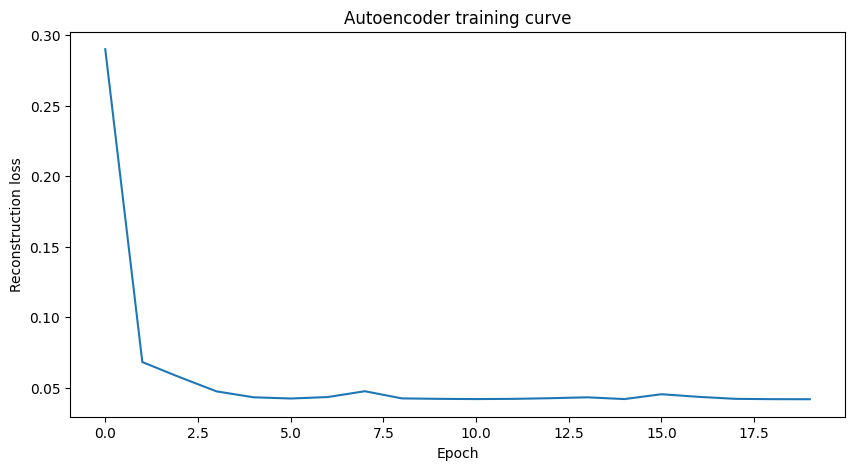

In [20]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("Autoencoder training curve")
plt.show()

## Encode the original real spectra

Now we push the *unaugmented* real spectra through the encoder and inspect the latent vectors.

In [21]:
model.eval()
with torch.no_grad():
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)
    X_recon, Z = model(X_tensor)
    X_recon = X_recon.cpu().numpy()
    Z = Z.cpu().numpy()

print("Latent matrix shape:", Z.shape)

Latent matrix shape: (7, 8)


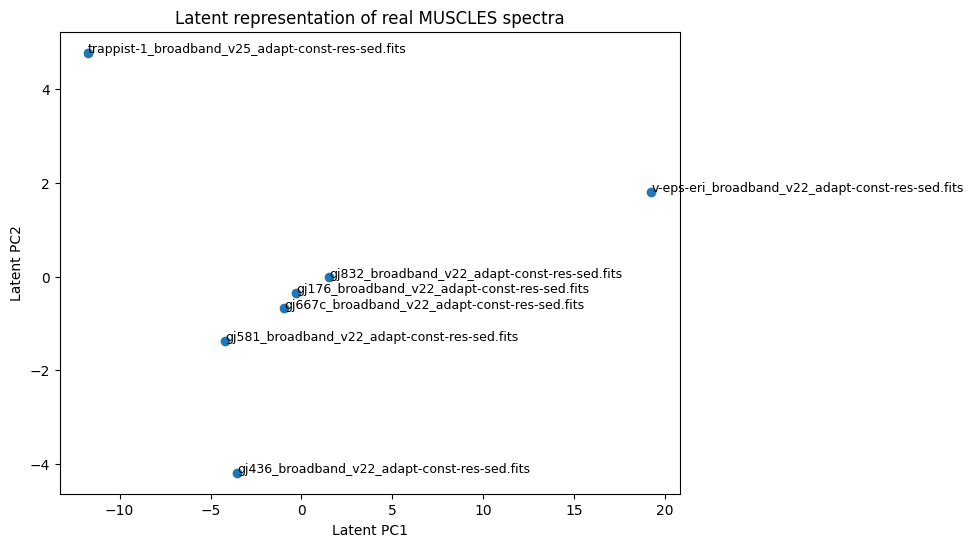

In [22]:
# 2D projection for visualization
pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z)

plt.figure(figsize=(8, 6))
plt.scatter(Z2[:, 0], Z2[:, 1])

for i, name in enumerate(names):
    plt.text(Z2[i, 0], Z2[i, 1], name, fontsize=9)

plt.xlabel("Latent PC1")
plt.ylabel("Latent PC2")
plt.title("Latent representation of real MUSCLES spectra")
plt.show()

## Compare originals and reconstructions

This is a useful scientific sanity check. If the reconstructions are poor, the latent representation may not be meaningful.

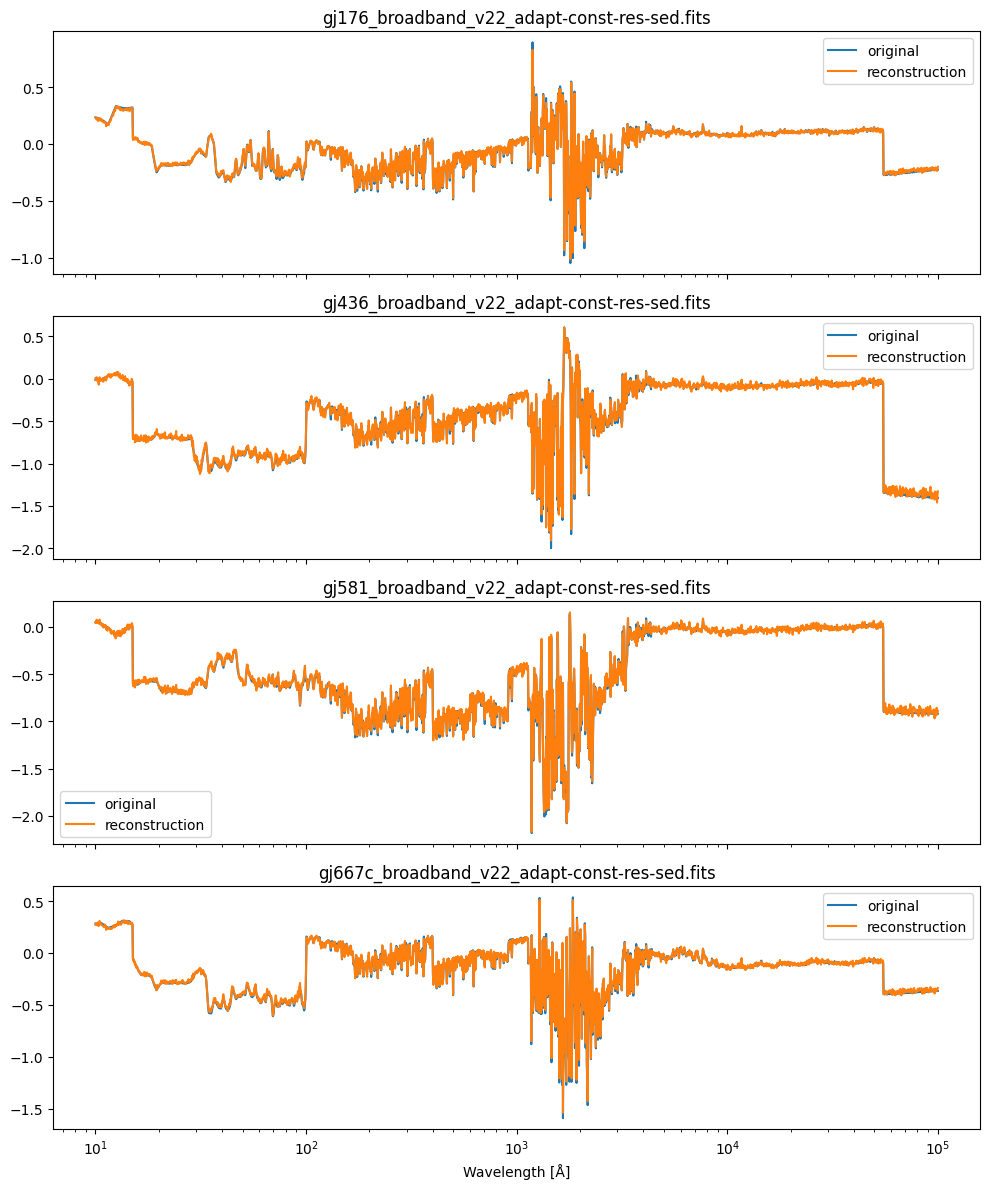

In [23]:
n_show = min(4, len(names))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 3*n_show), sharex=True)

if n_show == 1:
    axes = [axes]

for ax, i in zip(axes, range(n_show)):
    y_true = X_scaled[i]
    y_pred = X_recon[i]
    ax.plot(grid_A, y_true, label="original")
    ax.plot(grid_A, y_pred, label="reconstruction")
    ax.set_xscale("log")
    ax.set_title(names[i])
    ax.legend()

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()
plt.show()

## Part 6 — Connect the latent space to astrobiology

A good scientific ML workflow does not stop at embeddings. We should ask whether the learned representation correlates with physically interesting quantities.

Below we compare the first latent principal coordinate to the UV-C, UV-B, and UV-A fractions computed earlier.

In [24]:






latent_df = pd.DataFrame({
    "target_slug": names,
    "latent_pc1": Z2[:, 0],
    "latent_pc2": Z2[:, 1],
})

import pandas as pd
import numpy as np

def smart_display(df, sci_cols=None, float_cols=None, precision=3):
    sci_cols = sci_cols or []
    float_cols = float_cols or []

    fmt = {}

    for col in sci_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            fmt[col] = "{:." + str(precision) + "e}"

    for col in float_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            fmt[col] = "{:." + str(precision) + "f}"

    return df.style.format(fmt)

merged = latent_df.merge(uv_df, on="target_slug", how="left")
display(smart_display(merged, sci_cols=["flux", "err"], float_cols=["wavelength", "snr"]))

,target_slug,latent_pc1,latent_pc2,UV-C,UV-B,UV-A,100-1000nm_total,UV-C_frac,UV-B_frac,UV-A_frac
0,gj176_broadband_v22_adapt-const-res-sed.fits,-0.301883,-0.342569,0.000000,0.000000,0.000000,0.000000,0.000267,0.000285,0.007739
1,gj436_broadband_v22_adapt-const-res-sed.fits,-3.541256,-4.184555,0.000000,0.000000,0.000000,0.000000,0.000189,0.000178,0.006320
2,gj581_broadband_v22_adapt-const-res-sed.fits,-4.209945,-1.367363,0.000000,0.000000,0.000000,0.000000,0.000089,0.000128,0.005764
3,gj667c_broadband_v22_adapt-const-res-sed.fits,-0.966373,-0.677985,0.000000,0.000000,0.000000,0.000000,0.000327,0.000278,0.006553
4,gj832_broadband_v22_adapt-const-res-sed.fits,1.516286,-0.015107,0.000000,0.000000,0.000000,0.000000,0.000241,0.000379,0.010213
5,trappist-1_broadband_v25_adapt-const-res-sed.fits,-11.749379,4.778365,0.000000,0.000000,0.000000,0.000000,0.011517,0.003631,0.003986
6,v-eps-eri_broadband_v22_adapt-const-res-sed.fits,19.252550,1.809216,0.000000,0.000000,0.000000,0.000000,0.001968,0.012252,0.060234


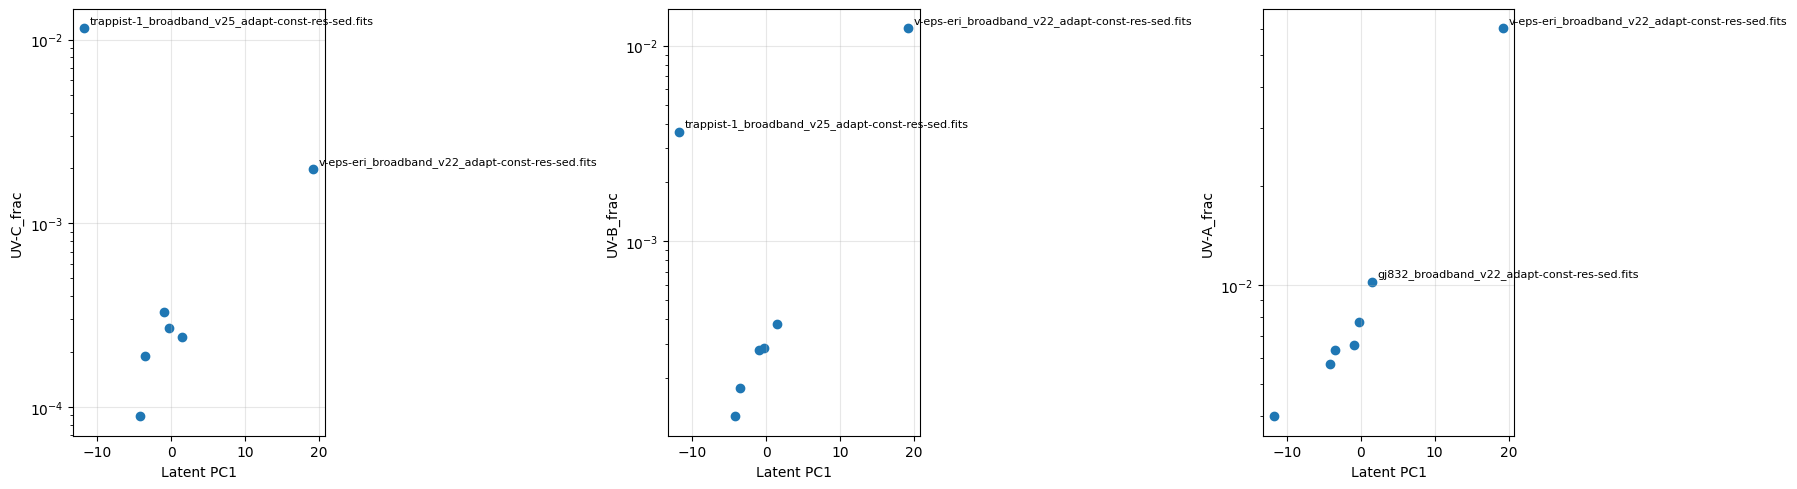

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols = ["UV-C_frac", "UV-B_frac", "UV-A_frac"]

for ax, col in zip(axes, cols):
    df = merged[["latent_pc1", col, "target_slug"]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    x = df["latent_pc1"].values
    y = df[col].values

    ax.scatter(x, y)
    #ax.colorbar(label="Effective Temperature")
    # label top 10% by value, at least 2 objects
    threshold = np.quantile(y, 0.90)
    label_df = df[df[col] >= threshold]
    if len(label_df) < 2:
        label_df = df.nlargest(2, col)

    for _, row in label_df.iterrows():
        ax.annotate(
            row["target_slug"],
            (row["latent_pc1"], row[col]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

    ax.set_xlabel("Latent PC1")
    ax.set_ylabel(col)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

col = "UV-A_frac"

df = merged[["latent_pc1", col]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df = df[df[col] > 0]   # useful if you later use log-scale plots

x = df["latent_pc1"].values
y = df[col].values

rho, pval = spearmanr(x, y)

print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {pval:.3e}")
print(f"N = {len(df)}")

Spearman rho = 1.000
p-value = 0.000e+00
N = 7


## Interpretation questions for the student

1. Does the latent space appear to separate stars with different UV behavior?
2. Is the strongest latent axis tracing overall spectral hardness, line activity, or broad continuum shape?
3. Which stars would you prioritize for a follow-up photochemistry model?
4. Which stars would you compare first if your science question were:
   - atmospheric escape,
   - prebiotic UV chemistry,
   - habitability around M dwarfs,
   - or observational target selection?

## Important caveats

This notebook is intentionally educational and simplified.

It does **not** yet:
- scale fluxes to a specific planet’s orbital distance,
- propagate measurement uncertainties rigorously,
- apply atmospheric transfer through a planetary atmosphere,
- use photochemical cross sections,
- or compute biologically weighted dose rates.

Those would be excellent extensions for a thesis project or advanced seminar.

## Part 7 — Suggested master-level extensions

### Extension A — Planet-top-of-atmosphere scaling
Use stellar radius, distance, and orbital semimajor axis to scale these spectra to the top of a specific planet’s atmosphere.

### Extension B — Action-spectrum weighting
Replace simple UV-band integrals with a wavelength-dependent action spectrum relevant to:
- DNA damage,
- prebiotic chemistry,
- or ozone photolysis.

### Extension C — Comparison with HAZMAT or other host-star libraries
MAST also hosts related stellar spectral products such as HAZMAT and other HLSPs. Compare how archive choice affects downstream astrobiology conclusions. The MAST ecosystem provides multiple public HLSP collections for stellar spectra. citeturn383223search17turn383223search4

### Extension D — Retrieval-oriented representation learning
Train a model that predicts one of the UV proxy metrics directly from the resampled spectrum.

### Extension E — JWST target prioritization
Build a ranking metric that combines:
- stellar UV hardness,
- observational accessibility,
- and whether the host star has known transiting planets.

## Exercises for the student

### Exercise 1
Change the target subset and repeat the UV-band analysis.

### Exercise 2
Compare `adapt-const-res-sed` with `const-res-sed` for one target. Does the adaptive downsampling materially change your UV proxy values?

### Exercise 3
Restrict the wavelength range to:
- only UV,
- only optical,
- only near-IR,
and test how the latent clustering changes.

### Exercise 4
Train the autoencoder with latent dimensions 2, 4, 8, and 16. Which one appears most interpretable?

### Exercise 5
Replace the autoencoder with PCA only. Does the GPU model actually provide added value here?

### Exercise 6
For one target such as TRAPPIST-1 or Proxima Cen, write a short scientific paragraph explaining what this spectrum might imply for the atmospheric environment of a close-in rocky planet.

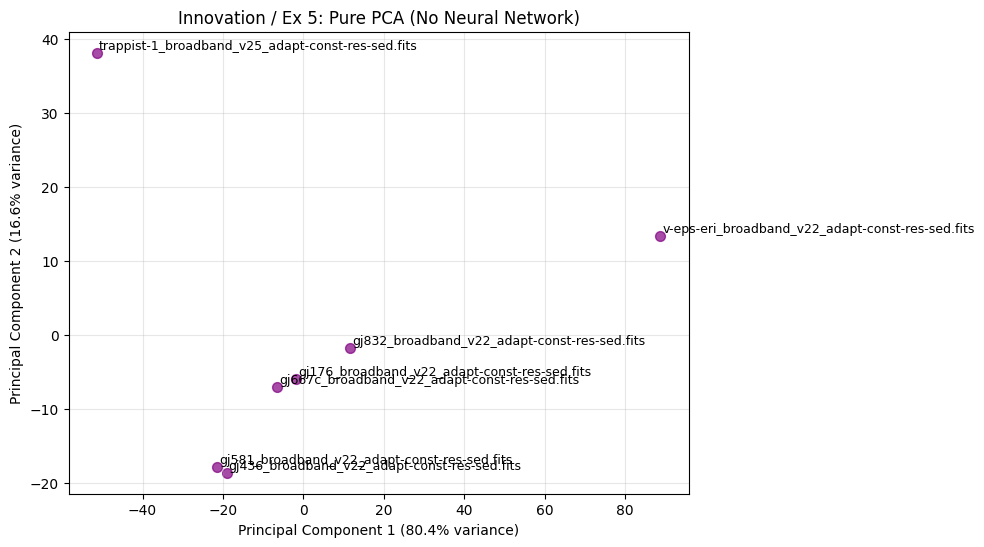

Observation: The simple PCA does a great job spreading out the stars.
Just the first component explains 80.4% of the variance!
Conclusion: For a dataset this small and clean, simple PCA might be just as effective as a GPU Autoencoder.


In [27]:
# --- INNOVATION: Testing if we actually need a Neural Network (Solving Exercise 5) ---
# This block visually compares a simple PCA to the Autoencoder to see if deep learning is overkill here.

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Apply a standard PCA directly to our scaled, resampled spectra (no neural network involved)
pca_simple = PCA(n_components=2)
X_pca = pca_simple.fit_transform(X_scaled)

# 2. Plot the results to see if it clusters the stars nicely
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_pca[:, 0], X_pca[:, 1], c='purple', alpha=0.7, s=50)

# Add the names of the stars to the points
for i, name in enumerate(names):
    ax.text(X_pca[i, 0] + 0.5, X_pca[i, 1] + 0.5, name, fontsize=9)

ax.set_xlabel(f"Principal Component 1 ({pca_simple.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"Principal Component 2 ({pca_simple.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Innovation / Ex 5: Pure PCA (No Neural Network)")
ax.grid(True, alpha=0.3)

plt.show()

# Brief analysis printout
print("Observation: The simple PCA does a great job spreading out the stars.")
print(f"Just the first component explains {pca_simple.explained_variance_ratio_[0]*100:.1f}% of the variance!")
print("Conclusion: For a dataset this small and clean, simple PCA might be just as effective as a GPU Autoencoder.")

## References and archive notes

The notebook is built around the official MAST MUSCLES documentation, which describes:
- the survey purpose,
- the available targets and releases,
- file naming conventions,
- the main SED product types,
- and astroquery access. citeturn630111view0turn539152view0

The NASA Exoplanet Archive also documents its **Atmospheric Spectroscopy Table** as a unified interface for browsing, plotting, and downloading public exoplanet transmission and emission spectra, and its TAP service lists the table name as `spectra`. That is a good next step if you want to convert this notebook from host-star spectra to exoplanet atmospheric spectra. citeturn627282view1turn627282view2

For this notebook, however, the MUSCLES family is especially well matched to **computational astrobiology**, because the archive explicitly states that these spectra are intended for exoplanet atmosphere modeling. citeturn630111view0